In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.linear_model import LinearRegression
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from matplotlib.animation import FuncAnimation, FFMpegWriter

save_figures = True

This notebook implements a reduced-order model for the coupled rotation and defect sweeping dynamics of a magnetic disk in a nematic liquid crystal. The model describes the coupled evolution of the disk orientation θ and a defect sweeping coordinate s, using an effective magnetic–elastic energy landscape and overdamped dynamics. The notebook illustrates forced rotation, defect sweeping, bifurcation structure, pinning effects, and relaxation trajectories. This is a simplified educational notebook accompanying ongoing manuscript work. It is not intended to reproduce the full experimental or finite-element analysis.

## Simulation of the disk under forced rotation

### Notations
We denote $\theta$ the orientation of the disk with respect to the equilibrium configuration absent the magnetic field, $\theta_B$ the orientation of the magnetic field that rotates with angular frequency $\Omega$ ($\theta_B = \Omega t + \theta_{B 0}$), $\theta_\mu$ the orientation of the disk permanent magnetic moment ($\theta_\mu = \theta +\theta_{\mu 0}$). For simplicity, we consider that at $t=0$, the magnetic field and the disk magnetic moment coincide ($\theta_{B 0}=\theta_{\mu 0}$), and the disk is at equilibrium ($\theta_0 =0$).

The defect location is the second degree of freedom of the system, we introduce it via the dimensionless variable $s = \frac{S}{\pi R^2}$ which is the fraction of the disk surface that has been swept by the defect. Note that $s$ is constrained between 0 (the defect has not swept yet) and 1 (defect has swept and reached the other side), this is implemented in the code via a sticking BC (clamping function).

### Free energy
We write the free energy of the system disk + NLC as

\begin{equation}
 U(s, \theta) = U_\text{magnetic}(\theta)+U_\text{elastic}(s,\theta)
\end{equation}

The magnetic free energy writes $U_\text{magnetic}=-\mu_B B \cos(\theta_B-\theta)$ (under the agreed assumptions).

The elastic free energy $U_\text{elastic}(s,\theta)=C_\text{twist}(s, \theta) + C_\text{pin}(s)$ includes 

the cost of twist in the gap $C_\text{twist}(s,\theta)=\frac{\pi R^2K}{2d}((1-s)\theta^2+s(\theta-2\pi)^2)$ as earlier. 

We consider here a new cost, a pinning energy penalizing the defect from detaching from the edge $C_\text{pin}(s) = P \sigma(\frac{s}{\epsilon})\sigma(\frac{1-s}{\epsilon})=P f(s)$. With $\epsilon$ small, the profile ressemble a square bump with steep slope near the boundaries $s=0, 1$. The height of the energy barrier is $P$. With $\alpha = \frac{\pi R^2K}{2d}$ and $\lambda =\frac{P}{\pi\alpha}$, we have $U_\text{elastic}(s,\theta)=\alpha\Big( (1-s)\theta^2+s(\theta-2\pi)^2+\pi\lambda f(s)\Big)$

We compare the scale of magnetic free energy to the scale of elastic free energy with $\kappa = \mu_\text{B} B / \alpha$.

The full free energy of the disk-defect system is

\begin{equation}
U(s, \theta) = \alpha\Big( -\kappa \cos(\theta_B-\theta)+(1-s)\theta^2 +s(\theta-2\pi)^2+\pi\lambda f(s) \Big)
\end{equation}


### Dynamics
We assume an overdamped dynamics, so the governing equations for the system are

\begin{align}
C_D \dot{\theta} &= -\partial_\theta U \\
C_W \dot{s} &= -\partial_s U, 
\end{align}

where $s$ is clamped clamped in the intervalle $[0,1]$, ie, if $s=0$ and $-\partial_s U<0$, we enforce $\dot{s}=0$, and if $s=1$ and $-\partial_s U>0$, we force $\dot{s}=0$.

### Rotating B

When we simulate the disk under constant rotation of the B-field, $\theta_B(t) = 2\pi t/T$, we render the equations non-dimensional by rescaling time as $\tilde{t}=t/T$. We identify two other timescales, the characteristic response time of the disk to the magnetic field $\tau_\mathrm{mag}=C_D/\mu_\text{B} B$ and the characteristic elastic relaxation time of the disk $\tau_\mathrm{elastic}=C_D/2\alpha$. With the 4 dimensionless parameters, $b=T/\tau_\mathrm{mag}$ and $a=T/\tau_\mathrm{elastic}$, $\mu=\frac{2 \pi C_D}{C_W}$ and $\lambda=\frac{P}{\pi \alpha}$, we obtain 

\begin{align}
\dot{\theta} &= b\sin(2\pi \tilde{t}-\theta)+a(2 \pi s - \theta)\\
\dot{s}&= \mu a (\theta-\pi)-\frac{1}{4}\mu a \lambda g(s)
\end{align}

where $g(s)=\frac{1}{\epsilon}\sigma(\frac{s}{\epsilon})\sigma(\frac{1-s}{\epsilon}) \left(\sigma(\frac{1-s}{\epsilon})-\sigma(\frac{s}{\epsilon})\right)$

Remark: the first equation is the balance of the magnetic, elastic and viscous torque on the disk. The second equation is the balance of effective forces acting on the defect.


### Bifurcation diagram
We analyze the system's stability when the magnetic field direction $\theta_B$ and the magnetic field strength $\kappa=\frac{2b}{a}=\frac{\mu_B B}{\alpha}$ are varied. To simplify, we do not consider the pinning potential in this part ($\lambda=0$). The free energy we consider is 

\begin{equation}
U(s, \theta) = \alpha\Big( -\kappa \cos(\theta_B-\theta)+(1-s)\theta^2 +s(\theta-2\pi)^2 \Big)
\end{equation}

### Parameter table

| Parameter | Expression | Physical meaning |
|---|---|---|
|  $a$ | $a = 2 \alpha T/C_D$ | strength of elastic effect |
|  $b$ | $b = \mu_\text{B} B T/C_D$ | strength of magnetic torque |
| $\kappa$ | $\kappa = 2b/a$ | relative strength of magnetic vs elastic torque |
| $\lambda$ | $\lambda=\frac{P}{\pi \alpha} $ | Pinning energy barrier relative to twist energy scale |
| $\mu$ | $\mu=\frac{2 \pi C_D}{C_W}$ | Relative drag ratio disk vs defect |




In [2]:
def sigmoid(x):
    # Numerically stable sigmoid
    out = np.empty_like(x, dtype=float)
    pos = x >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[~pos])
    out[~pos] = ex / (1.0 + ex)
    return out

def pinning_potential_hat(s, eps, P=1.0):
    """
    C_pin(s) = P * sigma(s/eps) * sigma((1-s)/eps)
    Works with scalar or numpy array s.
    """
    s = np.asarray(s, dtype=float)
    su = sigmoid(s / eps)
    sv = sigmoid((1.0 - s) / eps)
    return P * su * sv

def g_hat(s, eps):
    u = s / eps
    v = (1.0 - s) / eps
    su = sigmoid(np.array([u]))[0]
    sv = sigmoid(np.array([v]))[0]
    return (1.0 / eps) * su * sv * (sv - su)

def rhs_clamped(t, y, a, b, mu, lam, eps):
    theta, s = y

    # theta dynamics
    dtheta = b * np.sin(2.0 * np.pi * t - theta) + a * (2.0 * np.pi * s - theta)

    # s dynamics (UNclamped)
    ds_raw = mu * a * (theta - np.pi) - 0.25 * mu * lam * a * g_hat(s, eps)

    # clamp s in [0,1]
    if (s <= 0.0 and ds_raw < 0.0):
        ds = 0.0
    elif (s >= 1.0 and ds_raw > 0.0):
        ds = 0.0
    else:
        ds = ds_raw

    return [dtheta, ds]

def simulate(a, b, mu, lam, eps, theta0=0.0, s0=0.0,
             n_periods=1, n_eval_per_period=1500, method="RK45",
             rtol=1e-8, atol=1e-10, max_step=1e-3):

    t_span = (0.0, float(n_periods))
    t_eval = np.linspace(t_span[0], t_span[1], int(n_periods * n_eval_per_period) + 1)

    sol = solve_ivp(
        fun=lambda t, y: rhs_clamped(t, y, a=a, b=b, mu=mu, lam=lam, eps=eps),
        t_span=t_span,
        y0=[theta0, s0],
        t_eval=t_eval,
        method=method,
        rtol=rtol,
        atol=atol,
        max_step=max_step,
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    t = sol.t
    theta = sol.y[0]
    s = sol.y[1]
    return t, theta, s

def U_over_alpha_with_B(theta, s, kappa, theta_B):
    Uoveralpha = -kappa*np.cos(theta_B-theta)+ (1-s)*(theta**2) + s*((theta-2*np.pi)**2)
    return Uoveralpha

def plot_energy_landscape_with_B(kappa, theta_B, Ns=401, Nth=401,
                        cmap="BuPu", add_contours=True,
                        xlim=(-0.05, 1.05), ylim=(-0.1*np.pi, 2.1*np.pi),
                        n_levels=12, vmin=None, vmax=None, dummy_label ='',contour_kwargs=None, ax=None):
    """
    Plot U/alpha on the (delta_s, delta_theta) plane.
   
    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    # Grid
    s  = np.linspace(0, 1, Ns)
    th = np.linspace(0, +2*np.pi, Nth)
    S, TH = np.meshgrid(s, th, indexing="xy")
    Z = U_over_alpha_with_B(TH, S, kappa, theta_B)

     # If bounds not provided, compute from data
    if vmin is None:
        vmin = Z.min()
    if vmax is None:
        vmax = Z.max()


    # fontsize everywhere
    fs = 8
    mpl.rcParams.update({
        "font.size": fs,
        "axes.labelsize": fs,
        "axes.titlesize": fs,
        "xtick.labelsize": fs,
        "ytick.labelsize": fs,
        "legend.fontsize": fs,
    })

    # Figure setup
    fig_width_cm = 7
    fig_height_cm = 5
    cm_to_inch = 1 / 2.54
    fig_width = fig_width_cm * cm_to_inch
    fig_height = fig_height_cm * cm_to_inch
    if ax is None:
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    else:
        fig = ax.figure
    im = ax.imshow(
        Z,
        origin="lower",
        extent=[0, 1, 0, 2*np.pi],
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"$U(s,\theta)/\alpha$")

    if add_contours:
        levels = np.linspace(Z.min(), Z.max(), n_levels)
        ck = dict(linewidths=0.2, colors ='k')
        if contour_kwargs:
            ck.update(contour_kwargs)
        ax.contour(S, TH, Z, levels=levels, **ck)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    theta_ticks = [0, np.pi/2, np.pi, 1.5*np.pi, 2*np.pi]
    theta_ticklabels = [r"$0$", r"$\frac{1}{2}\pi$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"]
    ax.plot([],[],linestyle='none',label=dummy_label)
    ax.set_yticks(theta_ticks)
    ax.set_yticklabels(theta_ticklabels)
    ax.legend(frameon=False)
    #ax.set_title(rf"$U/\alpha$  ($\lambda={lam}$)")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$\theta$")

    plt.tight_layout()

    return fig, ax



theta_ticks = [0, np.pi/2, np.pi, 1.5*np.pi, 2*np.pi]
theta_ticklabels = [r"$0$", r"$\frac{1}{2}\pi$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"]

### Bifurcation diagrams

#### Fixed points

Interior fixed points (minima, maxima, saddle points) are points where  $\mathbf{\nabla} U =0$. 

Boundary fixed points : however, since $s \in [0,1]$ via clamped dynamics, we also have to consider boundary fixed points, which satisfy:

for $s=0$, $\partial_\theta U = 0$ and $\partial_s U \geq 0$,

for $s=1$, $\partial_\theta U = 0$ and $\partial_s U \leq 0$.

Interior points $0<s<1$ : $\theta^\star = \pi$, $-\kappa \sin(\theta_B-\pi)+2(\pi-2\pi s^\star)=0$. Classification of the interior fixed point with the Hessian matrix 

\begin{equation}
\mathbf{H}(\theta,s)=
\begin{pmatrix}
\partial_{\theta \theta} U & \partial_{\theta s} U\\
\partial_{\theta s} U & \partial_{s s} U
\end{pmatrix}
=
\alpha
\begin{pmatrix}
\kappa \cos(\theta_B-\theta)+2 & -4\pi\\
-4\pi & 0
\end{pmatrix} 
\end{equation},

 $\text{det}\mathbf{H}= -(4\pi \alpha)^2 <0$ so interior fixed points, if they exist, are saddle-points.

Boundary fixed point $s=0$, $-\kappa \sin(\theta_B-\theta^{\star,0})+2\theta^{\star,0}=0$ and $\theta \leq \pi$. Stability, minimum if $\partial_{\theta \theta}U >0$, maximum if  $\partial_{\theta \theta}U <0$.

Boundary fixed point $s=1$, $-\kappa \sin(\theta_B-\theta^{\star,1})+2(\theta^{\star,1}-2\pi)=0$ and $\theta \geq \pi$.

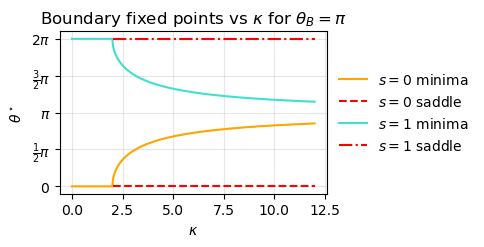

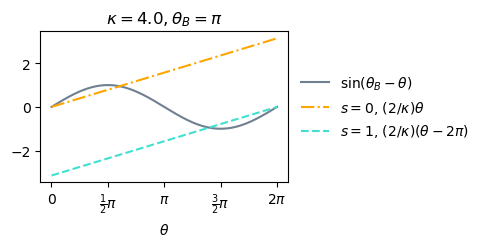

In [3]:

# ============================================================
# Parameters
# ============================================================
theta_B = 1 * np.pi         
kappa_vals = np.linspace(0.0, 12.0, 500)

# Search window for theta on s=0.
# For moderate kappa, roots stay in a finite interval around 0.
theta_min = 0
theta_max =  2*np.pi

# Numerical settings
n_scan = 4000
root_tol = 1e-10
merge_tol = 1e-7

# ============================================================
# Boundary equations
# ============================================================
def f_boundary_s0(theta, kappa, theta_B):
    """
    Fixed-point equation on boundary s=0:
        -kappa*sin(theta_B - theta) + 2*theta = 0
    """
    return -kappa * np.sin(theta_B - theta) + 2.0 * theta

def f_boundary_s1(theta, kappa, theta_B):
    """
    Fixed-point equation on boundary s=1:
        -kappa*sin(theta_B - theta) + 2*(theta - 2*pi) = 0
    """
    return -kappa * np.sin(theta_B - theta) + 2.0 * (theta - 2*np.pi)

def d2U_dtheta2(theta, kappa, theta_B, alpha=1.0):
    """
    Second derivative of U along theta on a fixed boundary branch.
    """
    return alpha * (kappa * np.cos(theta_B - theta) + 2.0)

# ============================================================
# Root finder for all boundary roots on s=0
# ============================================================
def unique_sorted(arr, tol=merge_tol):
    """
    Merge nearly identical roots.
    """
    if len(arr) == 0:
        return np.array([])
    arr = np.sort(np.array(arr))
    out = [arr[0]]
    for x in arr[1:]:
        if abs(x - out[-1]) > tol:
            out.append(x)
    return np.array(out)

def find_all_roots_s0(kappa, theta_B, theta_min, theta_max, n_scan=4000):
    """
    Find all roots of f_boundary_s0(theta)=0 in [theta_min, theta_max]
    by scanning for sign changes and refining with brentq.
    """
    thetas = np.linspace(theta_min, theta_max, n_scan)
    vals = f_boundary_s0(thetas, kappa, theta_B)

    roots = []

    # roots exactly on grid points
    for th, val in zip(thetas, vals):
        if abs(val) < 1e-12:
            roots.append(th)

    # roots bracketed by sign changes
    for i in range(len(thetas) - 1):
        a, b = thetas[i], thetas[i+1]
        fa, fb = vals[i], vals[i+1]

        if np.isnan(fa) or np.isnan(fb):
            continue

        if fa * fb < 0:
            try:
                r = brentq(f_boundary_s0, a, b, args=(kappa, theta_B), xtol=root_tol)
                roots.append(r)
            except ValueError:
                pass

    return unique_sorted(roots)

def find_all_roots_s1(kappa, theta_B, theta_min, theta_max, n_scan=4000):
    """
    Find all roots of f_boundary_s0(theta)=0 in [theta_min, theta_max]
    by scanning for sign changes and refining with brentq.
    """
    thetas = np.linspace(theta_min, theta_max, n_scan)
    vals = f_boundary_s1(thetas, kappa, theta_B)

    roots = []

    # roots exactly on grid points
    for th, val in zip(thetas, vals):
        if abs(val) < 1e-12:
            roots.append(th)

    # roots bracketed by sign changes
    for i in range(len(thetas) - 1):
        a, b = thetas[i], thetas[i+1]
        fa, fb = vals[i], vals[i+1]

        if np.isnan(fa) or np.isnan(fb):
            continue

        if fa * fb < 0:
            try:
                r = brentq(f_boundary_s1, a, b, args=(kappa, theta_B), xtol=root_tol)
                roots.append(r)
            except ValueError:
                pass

    return unique_sorted(roots)

# ============================================================
# Compute branches
# ============================================================
kappa_min_s0 = []
theta_min_s0 = []

kappa_max_s0 = []
theta_max_s0 = []

kappa_min_s1 = []
theta_min_s1 = []

kappa_max_s1 = []
theta_max_s1 = []

for kappa in kappa_vals:
    roots_s0 = find_all_roots_s0(kappa, theta_B, theta_min, theta_max, n_scan=n_scan)
    roots_s1 = find_all_roots_s1(kappa, theta_B, theta_min, theta_max, n_scan=n_scan)

    for th0 in roots_s0:
        curvature = d2U_dtheta2(th0, kappa, theta_B, alpha=1.0)

        if th0 < np.pi: #s stable
            if curvature > 0: #belongs to minimum branch
                kappa_min_s0.append(kappa)
                theta_min_s0.append(th0) 

            elif curvature < 0: #belongs to saddle branch
                kappa_max_s0.append(kappa)
                theta_max_s0.append(th0)

        else: #s is not stable
            # break the branch
            if curvature > 0:# NOT in minimum branch, break this branch
                kappa_min_s0.append(kappa)
                theta_min_s0.append(np.nan)
            if curvature < 0:#not in saddle branch, break this branch
                kappa_max_s0.append(kappa)
                theta_max_s0.append(np.nan)

    for th1 in roots_s1:
        curvature = d2U_dtheta2(th1, kappa, theta_B, alpha=1.0)

        if th1 > np.pi:
            if curvature > 0:
                kappa_min_s1.append(kappa)
                theta_min_s1.append(th1)

            elif curvature < 0:
                kappa_max_s1.append(kappa)
                theta_max_s1.append(th1)

        else:
            if curvature > 0:
                kappa_min_s1.append(kappa)
                theta_min_s1.append(np.nan)
            if curvature < 0:
                kappa_max_s1.append(kappa)
                theta_max_s1.append(np.nan)


# ============================================================
# Plot
# ============================================================



fig_width_cm = 12
fig_height_cm = 6
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch

fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

# s = 0 boundary
ax.plot(kappa_min_s0, theta_min_s0, 'o', color='orange', linestyle='-', ms=0, label=r'$s=0$ minima')
ax.plot(kappa_max_s0, theta_max_s0, 'o', color='red', linestyle='--', ms=0, label=r'$s=0$ saddle')

# s = 1 boundary
ax.plot(kappa_min_s1, theta_min_s1, 'd', color='turquoise', linestyle='-', ms=0, label=r'$s=1$ minima')
ax.plot(kappa_max_s1, theta_max_s1, 'd', color='red', linestyle='-.',  ms=0, label=r'$s=1$ saddle')

ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$\theta^\star$')
ax.set_yticks(theta_ticks)
ax.set_yticklabels(theta_ticklabels)
ax.set_title(rf'Boundary fixed points vs $\kappa$ for $\theta_B = \pi$')
ax.grid(True, alpha=0.3)
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
if save_figures:
    plt.savefig('figures/bifurcation_diagram_thetaB_pi.pdf',transparent=True, format="pdf", pad_inches=0)
plt.show()


theta_B=np.pi
kappa = 4.0
fig_width_cm = 12
fig_height_cm = 6
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch
fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
x = np.linspace(0,2*np.pi, 1000)
ax.plot(x, np.sin(theta_B-x), color='slategray', label=r'$\text{sin}(\theta_B-\theta)$')
ax.plot(x, (2/kappa)*x, color='orange', linestyle='-.',label=r'$s=0$, $(2/\kappa)\theta$')
ax.plot(x, (2/kappa)*(x-2*np.pi), color='turquoise', linestyle='--',label=r'$s=1$, $(2/\kappa)(\theta-2\pi)$')
ax.set_xlabel(r'$\theta$')
ax.set_xticks(theta_ticks)
ax.set_xticklabels(theta_ticklabels)
ax.set_title(rf'$\kappa={kappa}, \theta_B=\pi$')
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
if save_figures:
    plt.savefig('figures/finding_fixed_point_thetaB_pi.pdf',transparent=True, format="pdf", pad_inches=0)
plt.show()

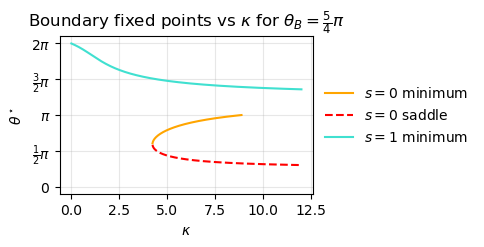

In [4]:
theta_B = 1.25*np.pi

# ============================================================
# Compute branches vs kappa
# ============================================================

kappa_plot = list(kappa_vals)

theta_min_s0 = []
theta_sad_s0 = []

theta_min_s1_low = []
theta_min_s1_high = []

theta_sad_s1 = []

tol = 1e-10

for kappa in kappa_vals:
    roots_s0 = find_all_roots_s0(kappa, theta_B, theta_min, theta_max, n_scan=n_scan)
    roots_s1 = find_all_roots_s1(kappa, theta_B, theta_min, theta_max, n_scan=n_scan)

    # -------------------------
    # classify admissible roots on s=0
    # -------------------------
    min_candidates_s0 = []
    sad_candidates_s0 = []

    for th0 in roots_s0:
        curvature = d2U_dtheta2(th0, kappa, theta_B, alpha=1.0)

        if th0 < np.pi + tol:   # admissible at s=0
            if curvature > tol:
                min_candidates_s0.append(th0)
            elif curvature < -tol:
                sad_candidates_s0.append(th0)

    min_candidates_s0 = sorted(min_candidates_s0)
    sad_candidates_s0 = sorted(sad_candidates_s0)

    # at most one s=0 minimum branch expected
    theta_min_s0.append(min_candidates_s0[0] if len(min_candidates_s0) >= 1 else np.nan)

    # at most one s=0 saddle branch expected
    theta_sad_s0.append(sad_candidates_s0[0] if len(sad_candidates_s0) >= 1 else np.nan)

    # -------------------------
    # classify admissible roots on s=1
    # -------------------------
    min_candidates_s1 = []
    sad_candidates_s1 = []

    for th1 in roots_s1:
        curvature = d2U_dtheta2(th1, kappa, theta_B, alpha=1.0)

        if th1 > np.pi - tol:   # admissible at s=1
            if curvature > tol:
                min_candidates_s1.append(th1)
            elif curvature < -tol:
                sad_candidates_s1.append(th1)

    min_candidates_s1 = sorted(min_candidates_s1)
    sad_candidates_s1 = sorted(sad_candidates_s1)

    # if there are two minima on s=1, split them into low/high branches
    theta_min_s1_low.append(min_candidates_s1[0] if len(min_candidates_s1) >= 1 else np.nan)
    theta_min_s1_high.append(min_candidates_s1[1] if len(min_candidates_s1) >= 2 else np.nan)

    # at most one saddle branch expected
    theta_sad_s1.append(sad_candidates_s1[0] if len(sad_candidates_s1) >= 1 else np.nan)



fig_width_cm = 12
fig_height_cm = 6
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch

fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

# s = 0
ax.plot(kappa_plot, theta_min_s0, color='orange', linestyle='-', lw=1.5, label=r'$s=0$ minimum')
ax.plot(kappa_plot, theta_sad_s0, color='red', linestyle='--', lw=1.5, label=r'$s=0$ saddle')

# s = 1
ax.plot(kappa_plot, theta_min_s1_low, color='turquoise', linestyle='-', lw=1.5, label=r'$s=1$ minimum')


ax.set_xlabel(r'$\kappa$')
ax.set_ylabel(r'$\theta^\star$')
ax.set_yticks(theta_ticks)
ax.set_yticklabels(theta_ticklabels)
ax.set_title(rf'Boundary fixed points vs $\kappa$ for $\theta_B=\frac{{5}}{{4}}\pi$')
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

if save_figures:
    plt.savefig('figures/bifurcation_diagram_thetaB_1p25pi.pdf', transparent=True, format="pdf", pad_inches=0)

plt.show()

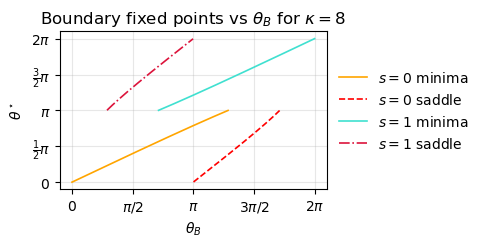

In [5]:
theta_B_vals = np.linspace(0, 2*np.pi, 500)
kappa = 8

# ============================================================
# Compute branches
# ============================================================

theta_B_min_s0 = []
theta_min_s0 = []

theta_B_max_s0 = []
theta_max_s0 = []

theta_B_min_s1 = []
theta_min_s1 = []

theta_B_max_s1 = []
theta_max_s1 = []

tol = 1e-10

for theta_B in theta_B_vals:
    roots_s0 = find_all_roots_s0(kappa, theta_B, theta_min, theta_max, n_scan=n_scan)
    roots_s1 = find_all_roots_s1(kappa, theta_B, theta_min, theta_max, n_scan=n_scan)

    # collect admissible candidates at this theta_B
    min_candidates_s0 = []
    max_candidates_s0 = []

    min_candidates_s1 = []
    max_candidates_s1 = []

    # ----- s = 0 boundary -----
    for th0 in roots_s0:
        curvature = d2U_dtheta2(th0, kappa, theta_B, alpha=1.0)

        if th0 < np.pi + tol:  # admissible boundary fixed point at s=0
            if curvature > tol:
                min_candidates_s0.append(th0)
            elif curvature < -tol:
                max_candidates_s0.append(th0)

    # ----- s = 1 boundary -----
    for th1 in roots_s1:
        curvature = d2U_dtheta2(th1, kappa, theta_B, alpha=1.0)

        if th1 > np.pi - tol:  # admissible boundary fixed point at s=1
            if curvature > tol:
                min_candidates_s1.append(th1)
            elif curvature < -tol:
                max_candidates_s1.append(th1)

    # sort candidates so branch selection is deterministic
    min_candidates_s0 = sorted(min_candidates_s0)
    max_candidates_s0 = sorted(max_candidates_s0)
    min_candidates_s1 = sorted(min_candidates_s1)
    max_candidates_s1 = sorted(max_candidates_s1)

    # append exactly one value per theta_B for each branch class
    theta_B_min_s0.append(theta_B)
    theta_min_s0.append(min_candidates_s0[0] if len(min_candidates_s0) > 0 else np.nan)

    theta_B_max_s0.append(theta_B)
    theta_max_s0.append(max_candidates_s0[0] if len(max_candidates_s0) > 0 else np.nan)

    theta_B_min_s1.append(theta_B)
    theta_min_s1.append(min_candidates_s1[0] if len(min_candidates_s1) > 0 else np.nan)

    theta_B_max_s1.append(theta_B)
    theta_max_s1.append(max_candidates_s1[0] if len(max_candidates_s1) > 0 else np.nan)

# ============================================================
# Plot
# ============================================================



theta_B_ticks = [0, 0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
theta_B_tick_labels = ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']

fig_width_cm = 12
fig_height_cm = 6
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch

fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

# s = 0 boundary
ax.plot(theta_B_min_s0, theta_min_s0, color='orange', linestyle='-', lw=1.2, label=r'$s=0$ minima')
ax.plot(theta_B_max_s0, theta_max_s0, color='red', linestyle='--', lw=1.2, label=r'$s=0$ saddle')

# s = 1 boundary
ax.plot(theta_B_min_s1, theta_min_s1, color='turquoise', linestyle='-', lw=1.2, label=r'$s=1$ minima')
ax.plot(theta_B_max_s1, theta_max_s1, color='crimson', linestyle='-.', lw=1.2, label=r'$s=1$ saddle')



ax.set_xlabel(r'$\theta_B$')
ax.set_ylabel(r'$\theta^\star$')
ax.set_xticks(theta_B_ticks)
ax.set_xticklabels(theta_B_tick_labels)
ax.set_yticks(theta_ticks)
ax.set_yticklabels(theta_ticklabels)
ax.set_title(rf'Boundary fixed points vs $\theta_B$ for $\kappa={kappa}$')
ax.grid(True, alpha=0.3)
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
if save_figures:
    plt.savefig('figures/bifurcation_diagram_kappa_8.pdf',transparent=True, format="pdf", pad_inches=0)
plt.show()

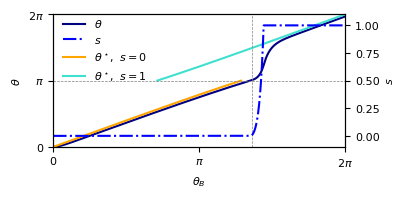

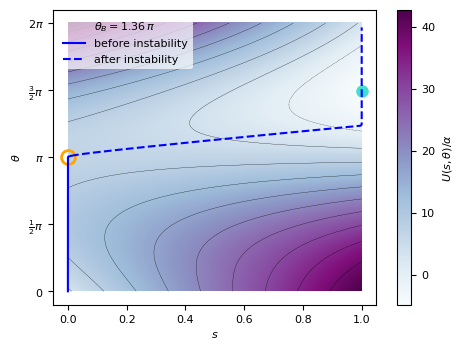

minU = -8.0
maxU = 47.47562993930822


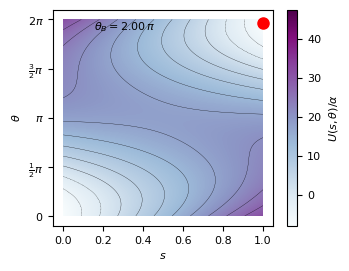

In [ ]:
# ------------------------------------------------------------
# Plot theta(t) and s(t) on the same plot
# ------------------------------------------------------------
# left axis theta, right axis s 
#optional : make animation of the trajectory over instantaneous energy landscape (magnetic + elastic)

animation = True

a = 10.0
b = 40.0
mu = 10.0
lam = 0.0
eps = 1e-2
kappa = 2 * b / a

# ------------------------------------------------------------
# Simulate trajectory
# ------------------------------------------------------------
t, theta, s = simulate(
    a, b, mu, lam, eps,
    theta0=0.0, s0=0.0,
    n_periods=1,
    n_eval_per_period=1500,
    method="RK45",
    rtol=1e-8, atol=1e-10, max_step=1e-3
)

#Find sweeping time tsweep, theta(tsweep), s(tsweep)
# sweeping time: first time s > s_threshold = 5e-2
s_threshold = 1e-2
idx = np.where(s > s_threshold)[0]

if idx.size == 0:
    t_sweep_values = np.nan
    theta_sweep_values = np.nan
else:
    i0 = idx[0]
    t_sweep = t[i0]
    theta_sweep= theta[i0]


fs = 8
mpl.rcParams.update({
    "font.size": fs,
    "axes.labelsize": fs,
    "axes.titlesize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
})

theta_ticks = [0, np.pi, 2*np.pi]
theta_tick_labels = ['0', r'$\pi$', r'$2\pi$']

fig_width_cm = 10
fig_height_cm = 4.75
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch

fig, ax1 = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)

t_over_T = t

# left axis: theta
line1, = ax1.plot(
    2*np.pi*t_over_T, theta,
    color='navy',
    linewidth=1.5,
    label=r'$\theta$'
)
branch_s0, = ax1.plot(
    theta_B_min_s0, theta_min_s0,
    color='orange', linestyle='-', lw=1.5,
    label=r'$\theta^\star,\ s=0$'
)

branch_s1, = ax1.plot(
    theta_B_min_s1, theta_min_s1,
    color='turquoise', linestyle='-', lw=1.5,
    label=r'$\theta^\star,\ s=1$'
)

ax1.set_xlabel(r'$\theta_B$')
ax1.set_ylabel(r'$\theta$')
ax1.tick_params(axis='y', colors='black')
ax1.tick_params(axis='x', colors='black')
ax1.set_xlim(0, 2*np.pi)
ax1.set_ylim(0, 2*np.pi)
ax1.set_yticks(theta_ticks)
ax1.set_yticklabels(theta_tick_labels)
ax1.set_xticks(theta_ticks)
ax1.set_xticklabels(theta_tick_labels)
ax1.axhline(y=np.pi, color='gray', linewidth=0.5, linestyle='--')
ax1.axvline(x=2*np.pi*t_sweep, color='gray', linewidth=0.5, linestyle='--')

# right axis: s
ax2 = ax1.twinx()
line2, = ax2.plot(
    2*np.pi*t_over_T, s,
    color='blue',
    linestyle='-.',
    linewidth=1.5,
    label=r'$s$'
)
ax2.set_ylabel(r'$s$')
ax2.tick_params(axis='y', colors='black')
ax2.set_ylim(-0.1, 1.1)

# make spines black
for spine in ax1.spines.values():
    spine.set_color('black')
for spine in ax2.spines.values():
    spine.set_color('black')

lines = [line1, line2, branch_s0, branch_s1]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left',
    bbox_to_anchor=(0.0, 1.05), frameon=False)
if save_figures:
    plt.savefig('figures/rotation_dynamics_kappa_8.pdf',
            transparent=True, format="pdf", pad_inches=0)
plt.show()

#Plot landscape theta_B(tsweep), with sweeping position theta(tsweep), s(tsweep)
theta_B = 2*np.pi*t_sweep

# Figure setup
fig_width_cm = 12
fig_height_cm = 9
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

plot_energy_landscape_with_B(
        kappa,
        theta_B,
        ax=ax,
        dummy_label=rf'$\theta_B = {theta_B/np.pi:.2f}\,\pi$'
    )
    
ax.plot(
        0,
        np.pi,
        marker='o',
        markersize=10,
        markeredgecolor='orange',
        markeredgewidth=2,
        markerfacecolor='None',
        linestyle='None'
    )

#plot global minimum for theta_B

tol = 1e-2
idx = np.where(np.isclose(theta_B_min_s1, theta_B, atol=tol, rtol=0))[0]
theta_at_that_theta_B = theta_min_s1[idx[0]]

ax.plot(
        1,
        theta_at_that_theta_B,
        marker='o',
        markersize=8,
        markeredgecolor='turquoise',
        markerfacecolor='turquoise',
        linestyle='None'
    )

ax.plot(
        s[:i0],
        theta[:i0],
        marker='None',
        color='blue',
        linestyle='-',
        linewidth=1.5,
        label='before instability'
    )

ax.plot(
        s[i0:],
        theta[i0:],
        marker='None',
        color='blue',
        linestyle='--',
        linewidth=1.5,
        label='after instability'
    )

leg = plt.legend(frameon=True)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.7)
leg.get_frame().set_edgecolor('none')
if save_figures:
    plt.savefig('figures/rotation_dynamics_on_landscape_kappa_8.pdf',
            transparent=True, format="pdf", pad_inches=0)
plt.show()





# Normalize time to [0, 1] for one cycle
t_norm = (t - t.min()) / (t.max() - t.min())

# ------------------------------------------------------------
# Interpolate solution for animation
# ------------------------------------------------------------
Nframes = 80
t_mov = np.linspace(0, 1, Nframes)

s_mov = np.interp(t_mov, t_norm, s)
theta_mov = np.interp(t_mov, t_norm, theta)

# ------------------------------------------------------------
# Find min/max of U(s,theta)/alpha over:
# the full cycle in theta_B and the full (s,theta) plane
# ------------------------------------------------------------
Ns = 300
Nth = 300
Ntb = 120

s_grid = np.linspace(0.0, 1.0, Ns)
theta_grid = np.linspace(0.0, 2 * np.pi, Nth)
theta_B_grid = np.linspace(0.0, 2 * np.pi, Ntb)

S, TH = np.meshgrid(s_grid, theta_grid, indexing="xy")

minU = np.inf
maxU = -np.inf

for theta_B in theta_B_grid:
    Ugrid = U_over_alpha_with_B(TH, S, kappa, theta_B)
    minU = min(minU, np.nanmin(Ugrid))
    maxU = max(maxU, np.nanmax(Ugrid))

print("minU =", minU)
print("maxU =", maxU)


# ------------------------------------------------------------
# Animation
# ------------------------------------------------------------

if animation:
    fig_width_cm = 9
    fig_height_cm = 7
    cm_to_inch = 1 / 2.54

    fig_width = fig_width_cm * cm_to_inch
    fig_height = fig_height_cm * cm_to_inch

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    def update(i):
        fig.clear()
        ax = fig.add_subplot(111)

        theta_B = 2 * np.pi * t_mov[i]

        plot_energy_landscape_with_B(
            kappa,
            theta_B,
            vmin=minU,
            vmax=maxU,
            ax=ax,
            dummy_label=rf'$\theta_B = {theta_B / np.pi:.2f}\,\pi$'
        )

        ax.plot(
            s_mov[i],
            theta_mov[i],
            marker='o',
            markersize=8,
            markeredgecolor='red',
            markerfacecolor='red',
            linestyle='None'
        )

        return ax,

    ani = FuncAnimation(
        fig,
        update,
        frames=Nframes,
        interval=80,
        blit=False
    )

    # ------------------------------------------------------------
    # Save as MP4
    # ------------------------------------------------------------
    writer = FFMpegWriter(
        fps=10,
        metadata=dict(artist="Claire"),
        bitrate=1800
    )

    ani.save(
        "figures/trajectory_over_landscape.mp4",
        writer=writer,
        dpi=300
    )

    plt.show()

### Effect of Pinning energy barrier on sweeping

A pinning energy for the defect delays sweeping to $\theta>\pi$. Theoretical prediction is $\theta_\text{unpin}=\pi + \frac{P}{16\epsilon}$ (steepest slope). We detect $\theta_\text{unpin}$ (start of sweeping) in simulations with the condition $s>s_\text{threshold}$, using $s_\text{threshold}=5\times10^{-2}$. We compare the numerical result to the theoretical prediction for 2 values of $\epsilon$, they fairly agree.

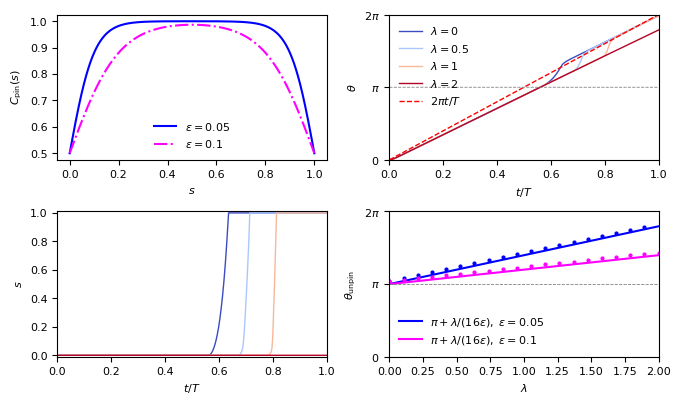

In [7]:
# -----------------------------
# Run a sweep over lambda to detect theta_unpin
# -----------------------------

lam_sweep_values = np.linspace(0,2,20)
t_sweep_values = np.zeros_like(lam_sweep_values)
theta_sweep_values = np.zeros_like(lam_sweep_values)


a = 10
b = 1e2
mu = 4
eps = 5e-2
s_threshold = 5e-2

for k, lam in enumerate(lam_sweep_values):
    t, theta, s = simulate(a=a, b=b, mu=mu, lam=lam, eps=eps,
                           theta0=0.0, s0=0.0,
                           n_periods=1, n_eval_per_period=1500,
                           method="RK45", max_step=1e-3)

    # Find sweeping time: first time s > s_threshold
    idx = np.where(s > s_threshold)[0]

    if idx.size == 0:
        t_sweep_values[k] = np.nan
        theta_sweep_values[k] = np.nan
    else:
        i0 = idx[0]
        t_sweep_values[k] = t[i0]
        theta_sweep_values[k] = theta[i0]

a = 10
b = 1e2
mu = 4
eps2 = 1e-1
s_threshold = 5e-2
t_sweep_values2 = np.zeros_like(lam_sweep_values)
theta_sweep_values2 = np.zeros_like(lam_sweep_values)

for k, lam in enumerate(lam_sweep_values):
    t, theta, s = simulate(a=a, b=b, mu=mu, lam=lam, eps=eps2,
                           theta0=0.0, s0=0.0,
                           n_periods=1, n_eval_per_period=1500,
                           method="RK45", max_step=1e-3)

    # Find sweeping time: first time s > s_threshold
    idx = np.where(s > s_threshold)[0]

    if idx.size == 0:
        t_sweep_values2[k] = np.nan
        theta_sweep_values2[k] = np.nan
    else:
        i0 = idx[0]
        t_sweep_values2[k] = t[i0]
        theta_sweep_values2[k] = theta[i0]


# -----------------------------
# Run a sweep over lambda values to plot some dynamics
# -----------------------------
lam_values = [0.0, 0.5, 1.0, 2.0]   # <-- put your list here

a = 10
b = 1e2
mu = 4
eps = 5e-2
eps2 = 1e-1

# fontsize everywhere
fs = 8
mpl.rcParams.update({
    "font.size": fs,
    "axes.labelsize": fs,
    "axes.titlesize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
})

# Figure setup
fig_width_cm = 17
fig_height_cm = 10
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch

fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height), constrained_layout=True)
ax0, ax1, ax2, ax3 = axes.ravel()

# Use a colormap for distinct colors
cmap = plt.get_cmap("coolwarm")
colors = cmap(np.linspace(0, 1, len(lam_values)))

handles_for_legend = []

# plot pinning potential
s_grid = np.linspace(0.0, 1.0, 2000)
P = 1.0
Cpin = pinning_potential_hat(s_grid, eps=eps, P=P)
Cpin2 = pinning_potential_hat(s_grid, eps=eps2, P=P)

ax0.plot(s_grid, Cpin, color='blue', linestyle='-', linewidth=1.5,
         label=rf'$\epsilon={eps}$')
ax0.plot(s_grid, Cpin2, color='fuchsia', linestyle='-.', linewidth=1.5,
         label=rf'$\epsilon={eps2}$')
ax0.set_xlabel(r"$s$")
ax0.set_ylabel(r"$C_{\rm pin}(s)$")
ax0.legend(frameon=False)

for lam, col in zip(lam_values, colors):
    t, theta, s = simulate(
        a=a, b=b, mu=mu, lam=lam, eps=eps,
        theta0=0.0, s0=0.0,
        n_periods=1, n_eval_per_period=1500,
        method="RK45", max_step=1e-3
    )

    lab = fr"$\lambda={lam:g}$"

    # 1) theta vs time
    h1, = ax1.plot(t, theta, color=col, lw=1, label=lab)
    handles_for_legend.append(h1)

    # 2) s vs time
    ax2.plot(t, s, color=col, lw=1)

# ticks for theta axes
theta_ticks = [0, np.pi, 2*np.pi]
theta_ticklabels = [r"$0$", r"$\pi$", r"$2\pi$"]

ax1.set_yticks(theta_ticks)
ax1.set_yticklabels(theta_ticklabels)

ax1.plot(t, 2*np.pi*t, color="red", linestyle="--", lw=1, label=r"$2\pi t/T$")
ax1.plot(t, np.pi*np.ones_like(t), color="gray", linestyle="--", linewidth=0.6)

# Axis formatting
ax1.set_xlabel(r"$t/T$")
ax1.set_ylabel(r"$\theta$")
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 2*np.pi])
ax1.legend(loc="upper left", frameon=False)

ax2.set_xlabel(r"$t/T$")
ax2.set_ylabel(r"$s$")
ax2.set_xlim([0, 1])
ax2.set_ylim([-0.01, 1.01])

ax3.plot(lam_sweep_values, theta_sweep_values,
         marker='o', markersize=2, color='blue', linestyle='none')
ax3.plot(lam_sweep_values, lam_sweep_values/(16*eps) + np.pi,
         color='blue', linestyle='-',
         label=rf'$\pi + \lambda/(16\epsilon),\ \epsilon={eps}$')

ax3.plot(lam_sweep_values, theta_sweep_values2,
         marker='o', markersize=2, color='fuchsia', linestyle='none')
ax3.plot(lam_sweep_values, lam_sweep_values/(16*eps2) + np.pi,
         color='fuchsia', linestyle='-',
         label=rf'$\pi + \lambda/(16\epsilon),\ \epsilon={eps2}$')

ax3.plot(lam_sweep_values, np.pi*np.ones_like(lam_sweep_values),
         color="gray", linestyle="--", linewidth=0.6)

ax3.set_xlabel(r"$\lambda$")
ax3.set_ylabel(r"$\theta_{\rm unpin}$")
ax3.set_xlim([0, 2])
ax3.set_ylim([0, 2*np.pi])
ax3.set_yticks(theta_ticks)
ax3.set_yticklabels(theta_ticklabels)
ax3.legend(frameon=False)

for ax in axes.ravel():
    ax.tick_params(axis="both", which="both", labelsize=fs)

if save_figures:
    plt.savefig('figures/effect_of_pinning_energy.pdf', transparent=True, format="pdf", pad_inches=0)
plt.show()

## Simulation of the elastic relaxation and comparison with experiments

 The disk is rotated CCW to the angle $\theta_i$ by the rotating magnetic field, then the magnetic field is switched off ($B=0$) and the disk-defect system relaxes in the effective elastic energy landscape.

 Note : the dataset currently available is synthetic, it is intended to run the notebook.


tau_el_rev = 27.94119659472363 (s)
tau_el_irrev = 24.67975901955766 (s)
tau_D = 26.310477807140643 (s)


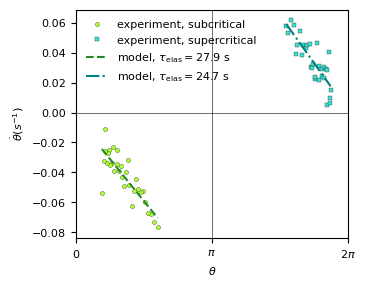

In [11]:
#1  Import experimental data time, theta, s for subcritical and supercritical dynamics

path = "synthetic_data_elastic_relaxation_theta_s.csv"  
epsilon = 1e-2

df_or = pd.read_csv(path, sep=";", decimal=',', usecols=[0, 1, 2, 3, 4, 5])
df_or = df_or.apply(lambda col: pd.to_numeric(col, errors="coerce"))
# data transformation (theta deg -> rad)
df = pd.DataFrame()

df['time_rev'] = df_or['time_rev [s]']
df['theta_rev']=df_or['theta_rev [deg]']*np.pi/180.0
df['s_rev']=df_or['s_rev']
df['time_irrev'] = df_or['time_irrev [s]']
df['theta_irrev']=df_or['theta_irrev [deg]']*np.pi/180.0
df['s_irrev']=df_or['s_irrev']

# compute theta_dot in rad/s
df['theta_dot_rev'] = np.gradient(df['theta_rev'].to_numpy(), df['time_rev'].to_numpy())
df['theta_dot_irrev'] = np.gradient(df['theta_irrev'].to_numpy(), df['time_irrev'].to_numpy())

# select subdataframe for rev dynamics
df_rev = df[['time_rev','theta_rev','s_rev','theta_dot_rev']]
df_rev = df_rev.replace([np.inf, -np.inf], np.nan).dropna().copy()
df_rev = df_rev[np.isclose(df_rev['s_rev'], 0.0, atol=epsilon)].copy()#select dynamics outside of sweeping
df_rev = df_rev.sort_values("time_rev").iloc[3:].copy() #exclude 3 first data points as they look like outliers


#linear fit
model_rev = LinearRegression(fit_intercept=True)
x_rev = df_rev[['theta_rev']].to_numpy()
y_rev = df_rev['theta_dot_rev'].to_numpy()
model_rev.fit(x_rev, y_rev)

a_rev = float(model_rev.coef_[0])
b_rev = float(model_rev.intercept_)
tau_el_rev = -1.0 / a_rev   


print("tau_el_rev =", tau_el_rev, '(s)')

df_irrev = df[['time_irrev','theta_irrev','s_irrev','theta_dot_irrev']]
df_irrev = df_irrev.replace([np.inf, -np.inf], np.nan).dropna().copy()
df_irrev = df_irrev[np.isclose(df_irrev['s_irrev'], +1.0, atol=epsilon)].copy()#select dynamics outside of sweeping


#linear fit
model_irrev = LinearRegression(fit_intercept=True)
x_irrev = df_irrev[['theta_irrev']].to_numpy()
y_irrev = df_irrev['theta_dot_irrev'].to_numpy()
model_rev.fit(x_irrev, y_irrev)

a_irrev = float(model_rev.coef_[0])
b_irrev = float(model_rev.intercept_)
tau_el_irrev = -1.0 / a_irrev   


print("tau_el_irrev =", tau_el_irrev, '(s)')

tau_D = 0.5*(tau_el_rev + tau_el_irrev)
print("tau_D =", tau_D, '(s)')

#plot the data theta_dot vs theta and the fitted model


# fontsize everywhere
fs = 8
mpl.rcParams.update({
    "font.size": fs,
    "axes.labelsize": fs,
    "axes.titlesize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
})

# scatter data
fig_width_cm = 9
fig_height_cm = 7
cm_to_inch = 1 / 2.54
fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch
fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True) 

ax.plot(df_rev["theta_rev"], df_rev["theta_dot_rev"],marker = 'o', markersize = 3, markeredgecolor ='k', markeredgewidth=0.2,linewidth=0, color = 'greenyellow', label="experiment, subcritical")
ax.plot(df_irrev["theta_irrev"], df_irrev["theta_dot_irrev"], marker = 's', markersize = 3, markeredgecolor ='k', markeredgewidth=0.2,linewidth=0, color = 'turquoise', label="experiment, supercritical")

# fitted lines
x_line = np.linspace(df_rev["theta_rev"].min(), df_rev["theta_rev"].max(), 300).reshape(-1, 1)
y_line = a_rev*x_line + b_rev
ax.plot(x_line.ravel(), y_line, label=rf"model, $\tau_\mathrm{{elas}} = {tau_el_rev:.1f}\ \mathrm{{s}}$", color ='forestgreen',linestyle ='dashed')
x_line = np.linspace(df_irrev["theta_irrev"].min(), df_irrev["theta_irrev"].max(), 300).reshape(-1, 1)
y_line = a_irrev*x_line + b_irrev
ax.plot(x_line.ravel(), y_line, color='teal', label=rf"model, $\tau_\mathrm{{elas}} = {tau_el_irrev:.1f}\ \mathrm{{s}}$",linestyle ='dashdot')
ax.set_xticks(theta_ticks)
ax.set_xticklabels(theta_ticklabels)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot{\theta} (s^{-1})$")
ax.axhline(0, color='k',linewidth=0.4)
ax.axvline(np.pi, color= 'k', linewidth=0.4)
ax.legend(frameon=False)
if save_figures:
    plt.savefig('figures/theta_dot_vs_theta_outside_of_sweeping.pdf', transparent=True, pad_inches=0, format='pdf')
plt.show()


rev theta0 174.41286359470058 deg
rev S0 0.0845040139352301
irrev TH0 205.72810435862948 deg
irrev S0 0.2415846042582928


/var/folders/r_/_yjw633526n3ndf9d833kw0w0000gn/T/ipykernel_41932/2480462303.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


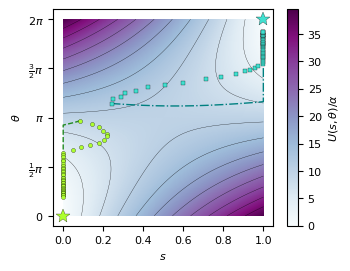

In [12]:
#2 Simulate subcritical and supercritical dynamics

#Parameters
a = 1.0
b = 0.0
kappa = 2*b/a
mu = 10
lam = 0 #no defect pinning
eps = 1e-2


#reversible
TH0 = df['theta_rev'].iloc[2]
S0  = df['s_rev'].iloc[2] 
print('rev theta0', 180*TH0/np.pi, 'deg')
print('rev S0', S0)

t_rev, theta_rev, s_rev = simulate(a, b, mu, lam, eps, theta0=TH0, s0=S0,
             n_periods=1, n_eval_per_period=1500, method="RK45",
             rtol=1e-8, atol=1e-10, max_step=1e-3)


#irreversible
TH0 = df['theta_irrev'].iloc[0]
S0  = df['s_irrev'].iloc[0] 
print('irrev TH0', 180*TH0/np.pi, 'deg')
print('irrev S0', S0)
t_irrev, theta_irrev, s_irrev = simulate(a, b, mu, lam, eps, theta0=TH0, s0=S0,
             n_periods=1, n_eval_per_period=1500, method="RK45",
             rtol=1e-8, atol=1e-10, max_step=1e-3)


# MAKE PLOT of experimental and simulated trajectories on s, theta plane

fig_width_cm = 9
fig_height_cm = 7
cm_to_inch = 1 / 2.54

fig_width = fig_width_cm * cm_to_inch
fig_height = fig_height_cm * cm_to_inch

fig, ax = plt.subplots(figsize=(fig_width, fig_height))


fig, ax = plot_energy_landscape_with_B(kappa=0, theta_B=0, ax=ax)


# PLOT SIMULATED TRAJECTORIES

# trajectory line WITH label
ax.plot(s_rev, theta_rev, linewidth=1, color='forestgreen', linestyle ='dashed',label=rf"$\mu={mu}$")


# trajectory line WITH label
ax.plot(s_irrev, theta_irrev, linewidth=1, color='teal',linestyle ='dashdot', label=rf"$\mu={mu}$")


#EXPERIMENTAL TRAJECTORIES
# --- Reversible (experimental) : markers only
drev = df[['s_rev', 'theta_rev']].replace([np.inf, -np.inf], np.nan).dropna()
ax.plot(drev['s_rev'].iloc[2:], drev['theta_rev'].iloc[2:], marker="o", markersize = 3, markeredgecolor='k', markeredgewidth=0.2, color ='greenyellow', linestyle="None",
 alpha=1.0)

# --- Irreversible (experimental) : markers only
dirrev = df[['s_irrev', 'theta_irrev']].replace([np.inf, -np.inf], np.nan).dropna()
ax.plot(dirrev['s_irrev'], dirrev['theta_irrev'], marker="s", color = 'turquoise',markeredgecolor='k', markeredgewidth=0.2, linestyle="None",
        markersize=3, alpha=1)

# end: star
ax.plot(0, 0, marker='*', markersize=10, markeredgecolor = 'k', markeredgewidth = 0.2, color='greenyellow')


# end: star
ax.plot(1.0, 2*np.pi, marker='*', markersize=10, markeredgecolor = 'k', markeredgewidth = 0.2,color='turquoise')

#ax.legend(loc="best", frameon=True)
if save_figures:
        plt.savefig('figures/relaxation_trajectories_on_landscape.pdf', transparent=True, pad_inches=0, format='pdf')

plt.show()
